# 🐾 AnimalCLEF2026 Competition: Official Starter notebook

The **Goal of the** [AnimalCLEF2026](https://www.kaggle.com/competitions/animal-clef-2026/) competition is to cluster individual animal (loggerhead sea turtles and Texas horned lizards) in photos. This notebook visualize the provided dataset and propose a baseline solution, based on the state-of-the-art re-identification model [MegaDescriptor](https://huggingface.co/BVRA/MegaDescriptor-L-384). It also suggests some possible improvements for the participants to follow.

The dataset is split into the training and test sets. For each image from the test set, the goal is to assing in a cluster. Each cluster should correspond to one individual animal. The cluster name must start with `cluster_SeaTurtleID2022_` or `cluster_TexasHornedLizards_`.

![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F12294787%2Ff015de35bcf462f36f74faabb20dd7e6%2FAnimalCLEF2026.png?generation=1767855188505985&alt=media)

## Dependencies instalation
For the competition we provide two Python packages for loading and preprocessing of available datasets ([wildlife-datasets](https://github.com/WildlifeDatasets/wildlife-datasets)) and tools / method for animal re-identification ([wildlife-tools](https://github.com/WildlifeDatasets/wildlife-tools)).

In [12]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as T
import timm
from transformers import AutoModel
from sklearn.cluster import DBSCAN
from wildlife_datasets.datasets import AnimalCLEF2026
from wildlife_tools.features import DeepFeatures
from wildlife_tools.similarity import CosineSimilarity
from dotenv import load_dotenv
load_dotenv() 

True

## 📊 Visualizing Data

Since `AnimalCLEF2015` is the child class of `datasets.WildlifeDataset` from [wildlife-datasets](https://github.com/WildlifeDatasets/wildlife-datasets/blob/main/wildlife_datasets/datasets/datasets.py), it inherits all its methods and attributes. Its integral part is the `transform` attribute, which performs transforms on the input images (such as converting them to torch tensors). We start with no transform.

In [13]:
root = 'data'
dataset_full = AnimalCLEF2026(
    root,
    transform=None,
    load_label=True,
    factorize_label=True,
    check_files=False
)

# print(dataset_full.metadata.head())
# print(dataset_full.metadata[['dataset', 'split']].value_counts(sort=False))

dataset_train = dataset_full.get_subset(dataset_full.df['split'] == 'train')
dataset_test = dataset_full.get_subset(dataset_full.df['split'] == 'test')

datasets = {}
for name in dataset_train.metadata['dataset'].unique():
    datasets[name + "_train"] = dataset_train.get_subset(dataset_train.df['dataset'] == name)

for name in dataset_test.metadata['dataset'].unique():
    datasets[name + "_test"] = dataset_test.get_subset(dataset_test.df['dataset'] == name)
datasets


{
    'LynxID2025_train': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f055ea80>,
    'SalamanderID2025_train': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f055f740>,
    'SeaTurtleID2022_train': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f055c680>,
    'LynxID2025_test': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f055db20>,
    'SalamanderID2025_test': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48fb9d3a40>,
    'SeaTurtleID2022_test': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f055f080>,
    'TexasHornedLizards_test': <wildlife_datasets.datasets.animal_clef.AnimalCLEF2026 object at 0x7c48f82ae090>
}

📌 **Plotting a sample grid** of the data. We see that there is a large variability in sea turtles, which were taken underwater in their natural habitat. On the other hands, the images of lizards were taken in captivity.

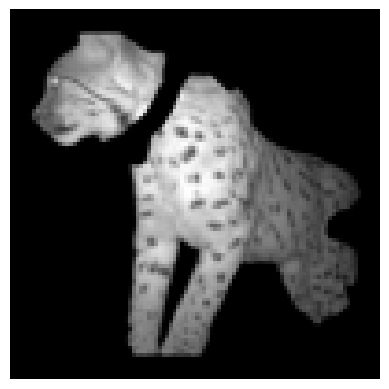

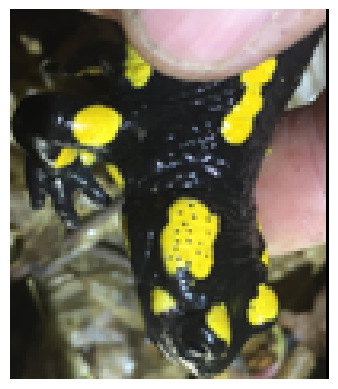

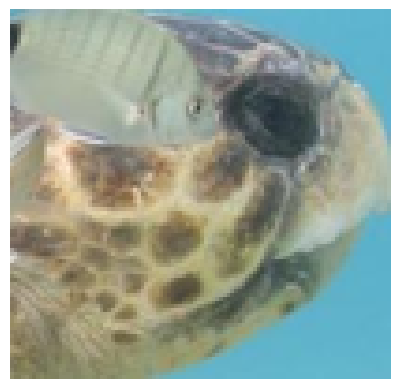

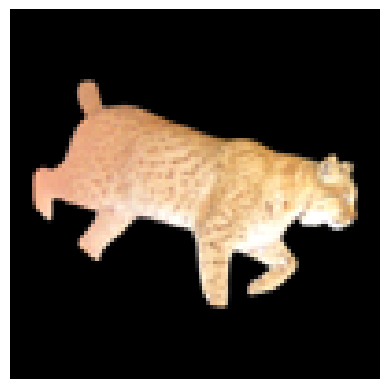

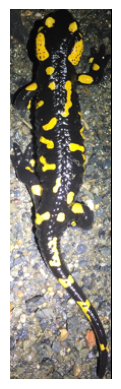

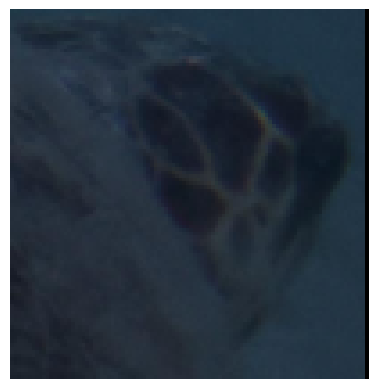

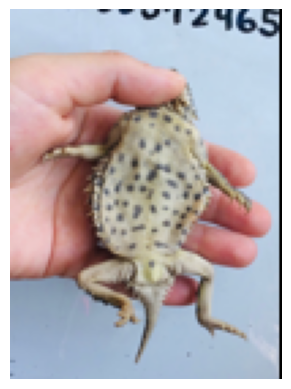

In [14]:
for dataset in datasets.values():
    dataset.plot_grid(n_rows=1, n_cols=1, rotate=False)

## Inference with MegaDescriptor and MiewID

Instead of training a classifier, we can just use out of the shelf pretrained models - [MegaDescriptor](https://huggingface.co/BVRA/MegaDescriptor-L-384) and [MiewID](https://huggingface.co/conservationxlabs/miewid-msv3). We use MegaDescriptor to extract features from sea turtles and MiewID for lizards and then cosine similarity to compute the similarity for each pair of images. Since the cosine similarity reflects the angle between the feature vectors, high similarity means that the feature vectors are close to each other and should depict the same individual.

**Note:** It is highly recommended to use the GPU acceleration.

In [16]:
import timm
import torchvision.transforms as T
from transformers import AutoModel
from transformers.dynamic_module_utils import get_class_from_dynamic_module


device = 'cuda'
batch_size = 32

similarities = {}
for name, dataset in datasets.items():
    # Select the model for feature extraction
    if name in ['SalamanderID2025_train', 'SeaTurtleID2022_train']:
        model = timm.create_model("hf-hub:BVRA/MegaDescriptor-L-384", pretrained=True).eval()
        size = 384
    elif name in ["LynxID2025_train", "TexasHornedLizards_train"]:
        MiewIdNet = get_class_from_dynamic_module(
            "modeling_miewid.MiewIdNet",
            "conservationxlabs/miewid-msv3",
        )
        if not hasattr(MiewIdNet, "all_tied_weights_keys"):
            MiewIdNet.all_tied_weights_keys = {}

        model = AutoModel.from_pretrained(
            "conservationxlabs/miewid-msv3",
            trust_remote_code=True,
        ).eval()
        size = 512
    else:
        raise ValueError('Name does not exist')

    # Set the extractor and transform for the images
    # matcher = CosineSimilarity()
    # extractor = DeepFeatures(model=model, device=device, batch_size=batch_size)
    # transform = T.Compose([
    #     T.Resize(size=(size, size)),
    #     T.ToTensor(),
    #     T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    # ])

    # # Set the transform for images
    # dataset.set_transform(transform)
    # # Extract features
    # features = extractor(dataset)
    # # Compute the similarity matrix
    # similarity = matcher(features, features)
    # similarities[name] = similarity

Building Model Backbone for efficientnetv2_rw_m model
config.model_name efficientnetv2_rw_m
model_name efficientnetv2_rw_m
final_in_features 2152


Loading weights: 100%|██████████| 1210/1210 [00:00<00:00, 12428.05it/s]


ValueError: Name does not exist

The next cell shows that TexasHornedLizards has 274 images. Each of the image has a feature vector of size 2152. The similarity matrix computes the similarity between each pair of images and therefore, it is symmetric and of size (274, 274).

In [ ]:
print(f'Dataset {name} with {len(dataset)} images.')
print(f'Features have size {features.features.shape}.')
print(f'Similarity matrix has shape {similarity.shape}.')

Dataset LynxID2025 with 946 images.


NameError: name 'features' is not defined

We intend to use the clustering algorithm DBSCAN on the similarity matrix. Since this algoritm return -1 for unclustered entries, we write a function `relabel_negatives`, which creates new clusters for these clusters (each new cluster with one element). For DBSCAN, we specify `min_samples=2` to allow for small clusters and select the epsilon parameters (determining the radius of the clusters) rather arbitrarily. Also due to DBSCAN requirements, we need to convert the similarity matrix into the distance matrix.

In [ ]:
def relabel_negatives(labels):
    labels = np.array(labels)
    neg_indices = np.where(labels == -1)[0]
    new_labels = np.arange(labels.max()+1, labels.max()+1+len(neg_indices))
    labels[neg_indices] = new_labels
    return labels

def run_DBSCAN(similarity, eps):
    # Convert similarity (high is good) to distance (small is good)
    distance = (np.max(similarity) - np.maximum(similarity, 0)) / np.max(similarity)
    # Obtain predictions
    clustering = DBSCAN(eps=eps, metric='precomputed', min_samples=2)
    clusters = clustering.fit(distance)
    # Relabel -1 clusters into separate clusters
    return relabel_negatives(clusters.labels_)

Now we run DBSCAN for all extracted similarity matrices and save the results. We select the parameter eps rather arbitrarily.

In [ ]:
results = None
eps_opt = {
    'LynxID2025': 0.3,
    'SalamanderID2025': 0.2,
    'SeaTurtleID2022': 0.4,
    'TexasHornedLizards': 0.24,
}
for name, similarity in similarities.items():
    # Save the clusters for one dataset
    clusters = run_DBSCAN(similarity, eps_opt[name])
    result = pd.DataFrame({
        'image_id': datasets[name].metadata['image_id'],
        'cluster': [f'cluster_{name}_{c}' for c in clusters]
    })
    # Merge the clusters to other datasets
    results = pd.concat((results, result))
results.to_csv('submission.csv', index=False)

## Visualizing parameter eps

We can run DBSCAN for multiple values or eps and visualize the number of clusters. Small eps correspond to 274 clusters (each cluster is one images) and large eps to 1 cluster (all images are in one cluster)

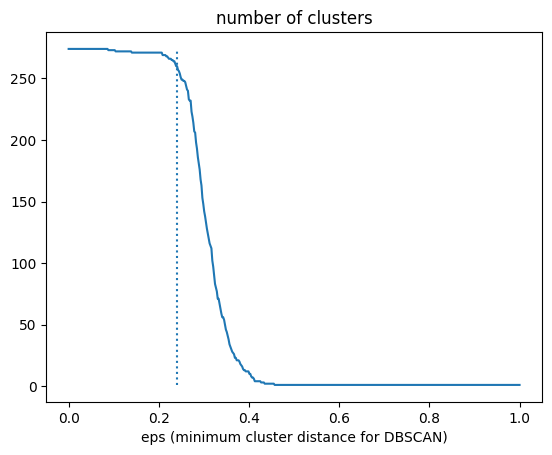

In [ ]:
eps_all = np.linspace(0.00001, 1, 500)
n_clusters = []
for eps in eps_all:
    clusters = run_DBSCAN(similarity, eps)
    n_clusters.append(len(np.unique(clusters)))

plt.plot(eps_all, n_clusters)
plt.vlines(eps_opt[name], min(n_clusters), max(n_clusters), linestyles='dotted')
plt.title('number of clusters')
plt.xlabel('eps (minimum cluster distance for DBSCAN)');

We can also inspect the images manually. Plotting the clusters shows that most of the clusters are correct (but ofr example  the last plotted cluster is wrong).

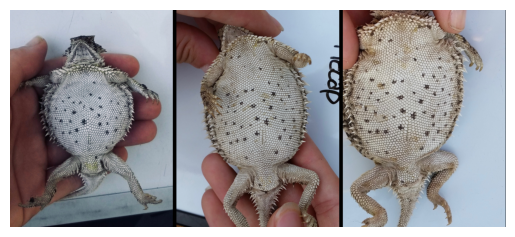

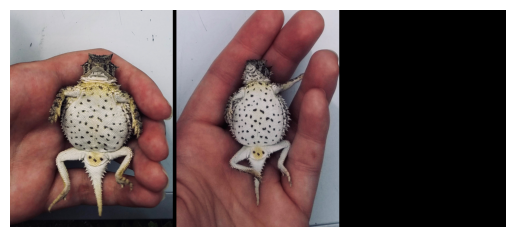

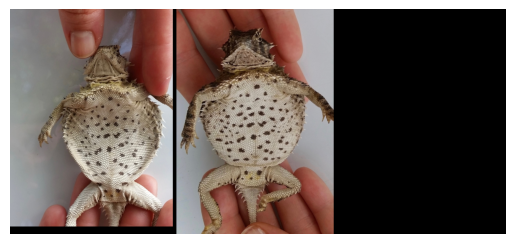

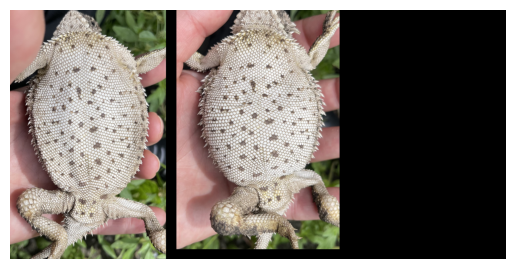

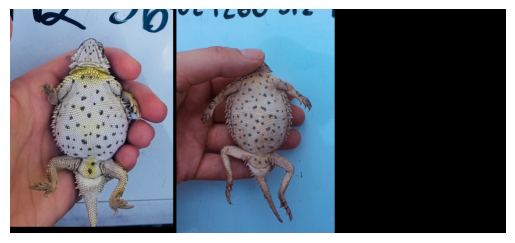

In [ ]:
clusters = run_DBSCAN(similarity, eps_opt[name])
n_plot = 5
i_plot = pd.Series(clusters).value_counts().index
for i in i_plot[:n_plot]:
    dataset.plot_grid(idx = clusters == i, n_cols=3, img_min=500, rotate=False)

## Possible improvements

There are many possible improvements to investigate. We list some of them:

* Use the training set, for example for validating the performance of hyperparameter selection.
* Use automatic tools for data preprocessing such as image segmentation.
* Replace MegaDescriptor or MiewID with another model. It is possible to use their combination, local feature models such as SuperPoint or any other.
* Replace DBSCAN by a method which is not so sensitive to its eps hyperparameters, for example HDBSCAN.